# Final product 2: Point to Area radius sensitivity based on cloud free composite.

In [2]:
import geopandas as gpd
import math
import pandas as pd
from shapely.geometry import Point, Polygon
import os
import dask
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import zarr
import re
import gc

In [ ]:
# to install geopy, open a terminal then:
# conda activate sentinelhub
# pip install geopy
import geopy.distance

In [3]:
# We will use xcube to access Sentinel-2 imagery and create a lazy xarray cube
from xcube.core.store import new_data_store


A spatial extent is a bounding box that specifies the minimum and maximum longitude and latitude of the region of interest you want to process.

By default, this latitude, and longitude values are expressed in the standard Coordinate Reference System for the world, which is EPSG:4623, also known as “WGS 84”, or just “lat-long”.

In this example, we will use a data point from one EC - tower

https://fluxnet.org/sites/siteinfo/ES-LM1


In [4]:
from pyproj import CRS, Transformer
from shapely.geometry import Point
from shapely.ops import transform

def geodesic_point_buffer(lat, lon, km):
    # Azimuthal equidistant projection
    aeqd_proj = CRS.from_proj4(
        f"+proj=aeqd +lat_0={lat} +lon_0={lon} +x_0=0 +y_0=0")
    tfmr = Transformer.from_proj(aeqd_proj, aeqd_proj.geodetic_crs)
    buf = Point(0, 0).buffer(km * 1000)  # distance in metres
    arr = np.array(transform(tfmr.transform, buf).exterior.coords[:])
    
    return [arr[:,0].min(), arr[:,1].min(), arr[:,0].max(), arr[:,1].max()]


We will create a bounding box based on a point and a radius in kilometers. In this example, the coordinates of the point are ```39.94269,-5.778683```, and the radius is ```10``` kilometers.

In [24]:
bbox_majadas = geodesic_point_buffer(39.94269,-5.778683, 10)
bbox_majadas

[-5.895689616343744, 39.85262641500765, -5.661676383656256, 40.03275218163678]

CDSE credentials for Sentinelhub, for more informantion see:

* How can I generate the credentials:
https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html

* How can I use xcube with SentinelHub:
https://xcube.readthedocs.io/en/latest/api.html#xcube.core.store.new_data_store


In [25]:
sh_config = dict(client_id = '',
                 client_secret =  '',
                 oauth2_url = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect',
                 api_url = 'https://sh.dataspace.copernicus.eu')

In [26]:
store = new_data_store('sentinelhub', **sh_config)

In [27]:
dataset_majadas = store.open_data('S2L2A',
                         variable_names = ['B07', 'B03', 'SCL'],
                         bbox = bbox_majadas,
                         spatial_res = 0.00018,
                         time_range = ('2023-03-01', '2023-09-01'),
                                 chunks={'time': -1, 
                                         'lat':-1,
                                        'lon':-1})

/opt/conda/envs/sentinelhub/lib/python3.10/site-packages/xcube_sh/sentinelhub.py:254: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(dt, infer_datetime_format=True, utc=True)
/opt/conda/envs/sentinelhub/lib/python3.10/site-packages/xcube_sh/sentinelhub.py:317: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  pd.to_timedelta(max_timedelta)


In [28]:
dataset_majadas

<xarray.Dataset>
Dimensions:    (time: 36, lat: 1001, lon: 1300, bnds: 2)
Coordinates:
  * lat        (lat) float64 40.03 40.03 40.03 40.03 ... 39.85 39.85 39.85 39.85
  * lon        (lon) float64 -5.896 -5.895 -5.895 ... -5.662 -5.662 -5.662
  * time       (time) datetime64[ns] 2023-03-02T11:20:08 ... 2023-08-29T11:20:17
    time_bnds  (time, bnds) datetime64[ns] dask.array<chunksize=(36, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    B03        (time, lat, lon) float32 dask.array<chunksize=(36, 1001, 1300), meta=np.ndarray>
    B07        (time, lat, lon) float32 dask.array<chunksize=(36, 1001, 1300), meta=np.ndarray>
    SCL        (time, lat, lon) uint8 dask.array<chunksize=(36, 1001, 1300), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   S2L2A Data Cube Subset
    history:                 [{'program': 'xcube_sh.chunkstore.SentinelHubChu...
    date_created:            2024-08-20T14:34:32.147126
    time_coverage_start:     2023-03-02T11:20:08.414000+00:00
    time_coverage_end:       2023-08-29T11:20:17.214000+00:00
    time_coverage_duration:  P180DT0H0M8.8S
    geospatial_lon_min:      -5.895689616343744
    geospatial_lat_min:      39.85262641500765
    geospatial_lon_max:      -5.661689616343744
    geospatial_lat_max:      40.03280641500765
    processing_level:        L2A

### Visual inspection of the cube

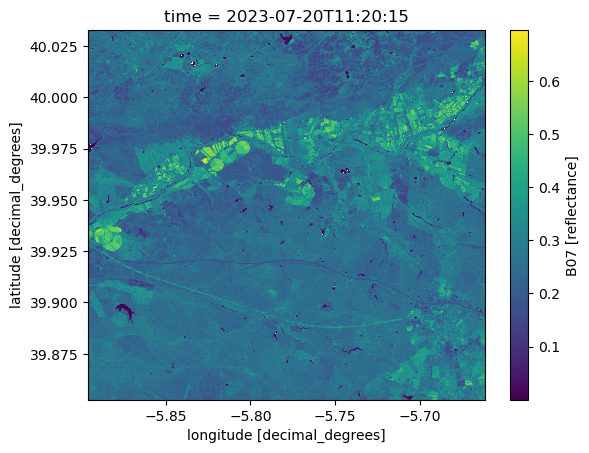

In [29]:
# Band B7
dataset_majadas['B07'].sel(time = "2023-07-20").plot()

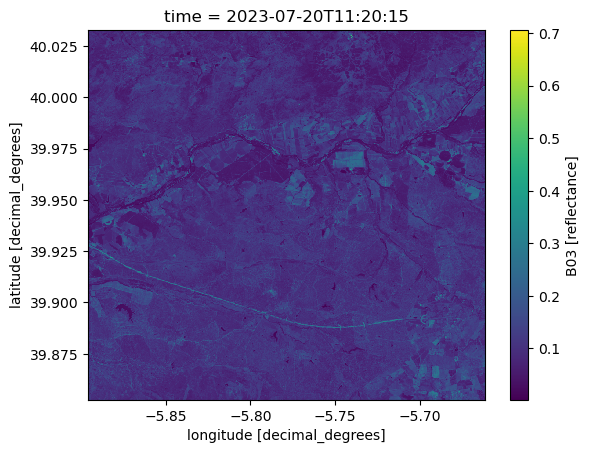

In [30]:
# Band B3
dataset_majadas['B03'].sel(time = "2023-07-20").plot()

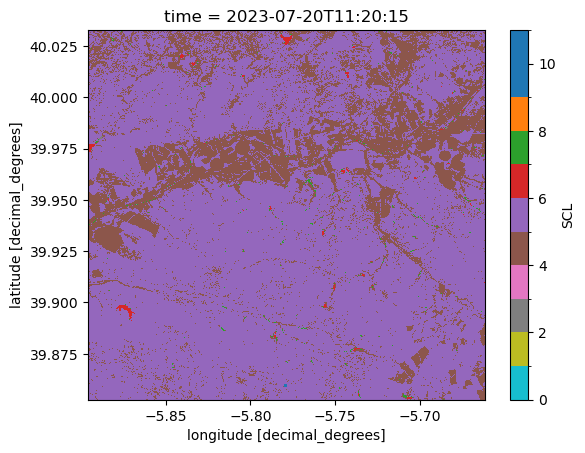

In [31]:
# Scene classification
dataset_majadas['SCL'].sel(time = '2023-07-20').plot(levels=[0, 1, 2,3,4,5,6,7,8,9,10,11], colors = 'tab10_r')

### Masking based on the SCL variable

In this exercise we will focus only on the differences of earth surface where we have good observations without clouds or clouds shadows, Then we will only consider the classes ```4,5,6,11``` corresponding to: 

4 => vegetation

5 => bare_soils

6 => water

11 => snow_or_ice

For more details on the Scene classes run ```store.describe_data('S2L2A')```

In [32]:
dataset_majadas_filtered = dataset_majadas.where(dataset_majadas['SCL'].isin([4,5,6,11]))

### Creating the composite

In [33]:
dataset_majadas_filtered = dataset_majadas_filtered.mean(dim = 'time', skipna = True)

### Computing Red-edge chlorophyll index (CIR)

In [34]:
cir = (dataset_majadas_filtered['B07'] /  dataset_majadas_filtered['B03']) - 1

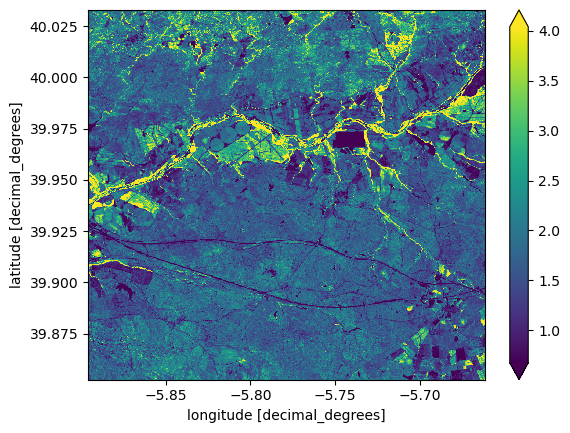

In [35]:
# Visual inspection of the CIR
cir.plot(robust=True)

### Creating a distance matrix from the eddy covariance tower

To mask values corresponding a certain distance from the tower we need to compute the distance of each pixel to the tower.

In [36]:
tower_location = (39.94269,-5.778683)

# Create a dummy matrix to save the data
dist_mat = np.zeros((len(cir.lat.data), len(cir.lon.data)))
lat = cir.lat.data
lon = cir.lon.data

In [37]:
#lat[0:len(lat)]

In [38]:
for la in range(len(lat)):
    for lo in range(len(lon)):
        dist_mat[la,lo] = geopy.distance.geodesic(tower_location, (lat[la], lon[lo])).m

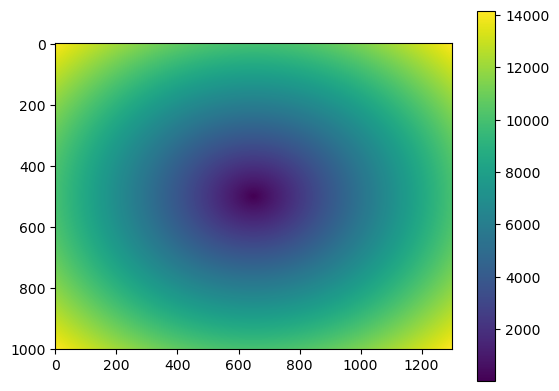

In [39]:
plt.imshow(dist_mat)
plt.colorbar()
plt.show()

Adding the distance_tower matrix to the CIR dataset

In [40]:
cir_dataset = cir.to_dataset(name = "cir")
cir_dataset

<xarray.Dataset>
Dimensions:  (lat: 1001, lon: 1300)
Coordinates:
  * lat      (lat) float64 40.03 40.03 40.03 40.03 ... 39.85 39.85 39.85 39.85
  * lon      (lon) float64 -5.896 -5.895 -5.895 -5.895 ... -5.662 -5.662 -5.662
Data variables:
    cir      (lat, lon) float32 dask.array<chunksize=(1001, 1300), meta=np.ndarray>

In [41]:
cir_dataset = cir_dataset.assign(distance_tower = (['lat', 'lon'], dist_mat))

In [42]:
cir_dataset

<xarray.Dataset>
Dimensions:         (lat: 1001, lon: 1300)
Coordinates:
  * lat             (lat) float64 40.03 40.03 40.03 40.03 ... 39.85 39.85 39.85
  * lon             (lon) float64 -5.896 -5.895 -5.895 ... -5.662 -5.662 -5.662
Data variables:
    cir             (lat, lon) float32 dask.array<chunksize=(1001, 1300), meta=np.ndarray>
    distance_tower  (lat, lon) float64 1.413e+04 1.412e+04 ... 1.413e+04

In [79]:
def dissimilarity(cube_cir, cube_dist, point_radius, area_radiuses):
    gc.collect()
    # allocating output object
    #out_tmp = np.full(len(tower_foot)*len(satellite_foot), np.nan)
    #print(f"received x of type {type(cube_tower)}, shape {cube_satellite.shape}")
    #print(f"received y of type {type(cube_satellite)}")
    
    cir = np.ravel(cube_cir)
    
    dist_matrix = np.ravel(cube_dist)

    cir_mask = dist_matrix <= point_radius

    point = np.where(cir_mask, cir, np.nan)

    point = point[~np.isnan(point)]

    output = np.empty([len(area_radiuses), 3])

    for i in range(len(area_radiuses)):
        tmp_mask = dist_matrix <= area_radiuses[i]
        
        area = np.where(tmp_mask, cir, np.nan)

    
        if np.isnan(point).all() or  np.isnan(area).all():
            output[i,:] = np.repeat(np.nan,3)
        
        else:
            
            area = area[~np.isnan(area)]
        
            try:
                # Estimate the KDE for each vector
                kde1 = scipy.stats.gaussian_kde(point)
                kde2 = scipy.stats.gaussian_kde(area)

                # Create a range of values for the x-axis
                x_values = np.linspace(min(point.min(), area.min()), max(point.max(), area.max()), 100)

                # Get the KDE values at specific points for each vector
                kde_values1 = kde1.evaluate(x_values)
                kde_values2 = kde2.evaluate(x_values)
            
                js_metric = scipy.spatial.distance.jensenshannon(kde_values1, kde_values2)
            
            except:
                js_metric = np.nan
    
    
                #e_statistics = energy_statistics.get_energy_statistics(tower, satellite)
    
            output[i,:] = np.array([js_metric, np.count_nonzero(~np.isnan(point)), np.count_nonzero(~np.isnan(area))])
    # e_statistics.e, e_statistics.t, e_statistics.h
    return(output)
    gc.collect()

### Estimating Jensen-Shannon distance from point to area

Defining a tower footprint (point) and one satellite footprint (area)

### Analysis set-up

In [80]:
point_r = [50]
area_radiuses = np.arange(50, 10000, 5)

In [81]:
results_cube = xr.apply_ufunc(dissimilarity, cir_dataset['cir'], cir_dataset['distance_tower'],
                              kwargs = {'point_radius':point_r, 'area_radiuses':area_radiuses},
                              input_core_dims=[['lat','lon'], ['lat','lon']],
                              output_core_dims=[['area_radius','stats']],
                              output_sizes = {'area_radius':len(area_radiuses) ,'stats':3},
                              output_dtypes= (np.float64, np.float64),
                              vectorize=True,
                              dask= "parallelized")

/tmp/ipykernel_94/293469842.py:1: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  results_cube = xr.apply_ufunc(dissimilarity, cir_dataset['cir'], cir_dataset['distance_tower'],


In [82]:
res = results_cube.compute()

In [84]:
res = res.assign_coords({"stats": ["JS","n_point", "n_area"]})
res = res.assign_coords({"area_radius": area_radiuses})
res

<xarray.DataArray (area_radius: 1990, stats: 3)>
array([[0.00000000e+00, 2.60000000e+01, 2.60000000e+01],
       [5.40441664e-02, 2.60000000e+01, 3.00000000e+01],
       [6.33665151e-02, 2.60000000e+01, 3.80000000e+01],
       ...,
       [2.94560635e-01, 2.60000000e+01, 1.01872100e+06],
       [2.94593376e-01, 2.60000000e+01, 1.01969400e+06],
       [2.94608299e-01, 2.60000000e+01, 1.02077800e+06]])
Coordinates:
  * stats        (stats) <U7 'JS' 'n_point' 'n_area'
  * area_radius  (area_radius) int64 50 55 60 65 70 ... 9975 9980 9985 9990 9995

In [88]:
tmp_dataframe = res.to_dataframe(name = 'cir')

In [89]:
tmp_dataframe

cir
area_radius stats                
50          JS       0.000000e+00
            n_point  2.600000e+01
            n_area   2.600000e+01
55          JS       5.404417e-02
            n_point  2.600000e+01
...                           ...
9990        n_point  2.600000e+01
            n_area   1.019694e+06
9995        JS       2.946083e-01
            n_point  2.600000e+01
            n_area   1.020778e+06

[5970 rows x 1 columns]

In [90]:
tmp_dataframe.to_csv("/home/jovyan/mystorage/results/ES-LM1_point_radius_sensitivity.csv")
gc.collect()

533

# Checking the results


In [91]:
majadas_res = pd.read_csv("/home/jovyan/mystorage/results/ES-LM1_point_radius_sensitivity.csv")
majadas_res

,area_radius,stats,cir
0,50,JS,0.000000e+00
1,50,n_point,2.600000e+01
2,50,n_area,2.600000e+01
3,55,JS,5.404417e-02
4,55,n_point,2.600000e+01
...,...,...,...
5965,9990,n_point,2.600000e+01
5966,9990,n_area,1.019694e+06
5967,9995,JS,2.946083e-01
5968,9995,n_point,2.600000e+01


<Axes: title={'center': 'Heterogeneity Analysis using multiple area radius \n Point radius:50'}, xlabel='Area Radius', ylabel='Jensen-Shannon'>

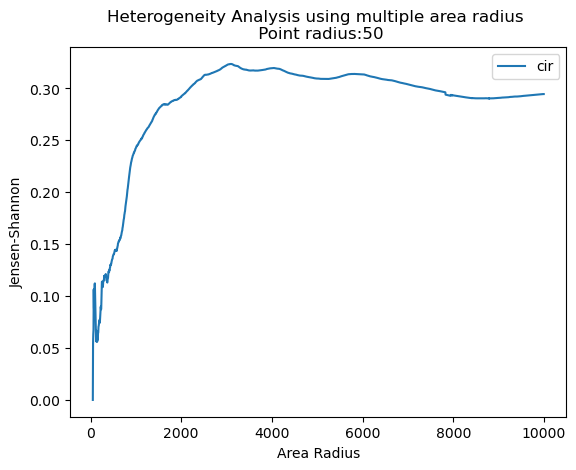

In [102]:
majadas_res[majadas_res['stats'] == 'JS'].plot(x = 'area_radius', y = 'cir', ylabel = 'Jensen-Shannon', xlabel = 'Area Radius', title = 'Heterogeneity Analysis using multiple area radius \n Point radius:' + str(point_r[0]))